# 07 — Меняется ли СКОРОСТЬ цены у уровня? (1h и 1m, с контролем)

Идея (user): speed = |return| за бар = темп движения. Если уровень — магнит
ликвидности, цена должна ТОРМОЗИТЬ, подходя к нему (лимитки гасят импульс).
Меряем speed как функцию расстояния до уровня. Unsigned — про темп, не направление.

**Контроль (урок nb06):** real уровни vs matched-fake (та же позиция-в-диапазоне,
но не пивот). Если у real скорость у dist→0 проседает СИЛЬНЕЕ, чем у matched —
это эффект уровня, а не расположения. Кросс-ТФ: уровни на 1h, скорость на 1h И 1m.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::7][:20]
START, END = "2024-01-01", "2024-07-01"
LIFE = 720; W = 720
DBINS = np.arange(0, 0.0205, 0.0015)   # distance-to-level bins, 0..2%
print(len(UNIV), "symbols:", UNIV)

20 symbols: ['API3USDT', 'AVAXUSDT', 'BELUSDT', 'CAKEUSDT', 'COREUSDT', 'DASHUSDT', 'ETHUSDT', 'GMTUSDT', 'HNTUSDT', 'IOTAUSDT', 'KNCUSDT', 'MTLUSDT', 'ONTUSDT', 'PEOPLEUSDT', 'ROSEUSDT', 'SCUSDT', 'SUPERUSDT', 'TRXUSDT', 'VETUSDT', 'XMRUSDT']


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i-k:i+k+1]; wL = l[i-k:i+k+1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i+k, h[i]))
    for i in np.where(lo)[0]: conf.append((i+k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life); px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint: segs.append((float(np.mean(c)), r, min(r+R, n), len(c)))
    return segs

def accumulate(prices, times_a, times_b, Ls, c_arr, ts_index, speed, sum_s, cnt_s):
    """For each level (L active over [ta,tb] timestamps), bin speed of bars in that
    window by distance |price-L|/L. Accumulates into sum_s/cnt_s by DBINS."""
    for L, ta, tb in zip(Ls, times_a, times_b):
        lo = np.searchsorted(ts_index, ta); hi = np.searchsorted(ts_index, tb)
        if hi - lo < 2: continue
        seg_c = c_arr[lo:hi]; seg_sp = speed[lo:hi]
        dist = np.abs(seg_c - L) / L
        bidx = np.digitize(dist, DBINS) - 1
        ok = (bidx >= 0) & (bidx < len(DBINS) - 1) & np.isfinite(seg_sp)
        np.add.at(sum_s, bidx[ok], seg_sp[ok]); np.add.at(cnt_s, bidx[ok], 1)

In [3]:
NB = len(DBINS) - 1
acc = {(tf, kind): [np.zeros(NB), np.zeros(NB)] for tf in ("1h", "1m") for kind in ("real", "matched")}

for si, sym in enumerate(UNIV):
    d1h = ohlcv(sym, START, END, "1h")
    if len(d1h) < W + 200: continue
    hi_w = pd.Series(d1h["high"]).rolling(W).max().to_numpy()
    lo_w = pd.Series(d1h["low"]).rolling(W).min().to_numpy(); span = hi_w - lo_w
    segs = [s for s in cluster_segments(d1h) if s[1] >= W and span[s[1]] > 0]
    if not segs: continue
    pos = np.array([(L - lo_w[a]) / span[a] for (L, a, b, strg) in segs])
    posp = rng.permutation(pos)
    Lr = np.array([L for (L, a, b, strg) in segs])
    Lm = np.array([lo_w[a] + posp[i] * span[a] for i, (L, a, b, strg) in enumerate(segs)])
    ta = d1h.index.values[[a for (L, a, b, strg) in segs]]
    tb = d1h.index.values[[b - 1 for (L, a, b, strg) in segs]]
    # 1h speed
    c1h = d1h["close"].to_numpy(); sp1h = np.abs(np.log(c1h / np.roll(c1h, 1))); sp1h[0] = np.nan
    accumulate(None, ta, tb, Lr, c1h, d1h.index.values, sp1h, *acc[("1h", "real")])
    accumulate(None, ta, tb, Lm, c1h, d1h.index.values, sp1h, *acc[("1h", "matched")])
    # 1m speed (same levels & windows, finer velocity)
    d1m = ohlcv(sym, START, END, "1min")
    c1m = d1m["close"].to_numpy(); sp1m = np.abs(np.log(c1m / np.roll(c1m, 1))); sp1m[0] = np.nan
    accumulate(None, ta, tb, Lr, c1m, d1m.index.values, sp1m, *acc[("1m", "real")])
    accumulate(None, ta, tb, Lm, c1m, d1m.index.values, sp1m, *acc[("1m", "matched")])
    if (si+1) % 5 == 0: print(f"  {si+1}/{len(UNIV)}")

centers = (DBINS[:-1] + DBINS[1:]) / 2 * 100
def profile(tf, kind):
    s, c = acc[(tf, kind)]; return np.where(c > 0, s / np.maximum(c, 1), np.nan) * 1e4  # speed in bp
for tf in ("1h", "1m"):
    print(f"\n{tf} mean speed (bp) by dist-to-level bin (0..2%):")
    print("  dist%:", np.round(centers, 2))
    print("  real :", np.round(profile(tf, "real"), 2))
    print("  match:", np.round(profile(tf, "matched"), 2))

  5/20


  10/20


  15/20


  20/20

1h mean speed (bp) by dist-to-level bin (0..2%):
  dist%: [0.08 0.23 0.38 0.52 0.68 0.82 0.98 1.12 1.28 1.42 1.58 1.72 1.88]
  real : [49.51 50.63 51.59 51.26 50.47 50.5  51.79 49.99 51.35 49.72 51.59 52.32
 50.02]
  match: [51.7  53.96 51.68 53.54 51.35 52.79 52.14 53.91 52.03 51.56 52.5  52.8
 53.27]

1m mean speed (bp) by dist-to-level bin (0..2%):
  dist%: [0.08 0.23 0.38 0.52 0.68 0.82 0.98 1.12 1.28 1.42 1.58 1.72 1.88]
  real : [6.4  6.51 6.56 6.57 6.54 6.52 6.47 6.52 6.59 6.58 6.59 6.54 6.62]
  match: [6.88 6.85 6.75 6.74 6.72 6.75 6.72 6.85 6.85 6.8  6.84 6.84 6.91]


[saved] notebooks\levels\_out\07_speed.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/07_speed.png')

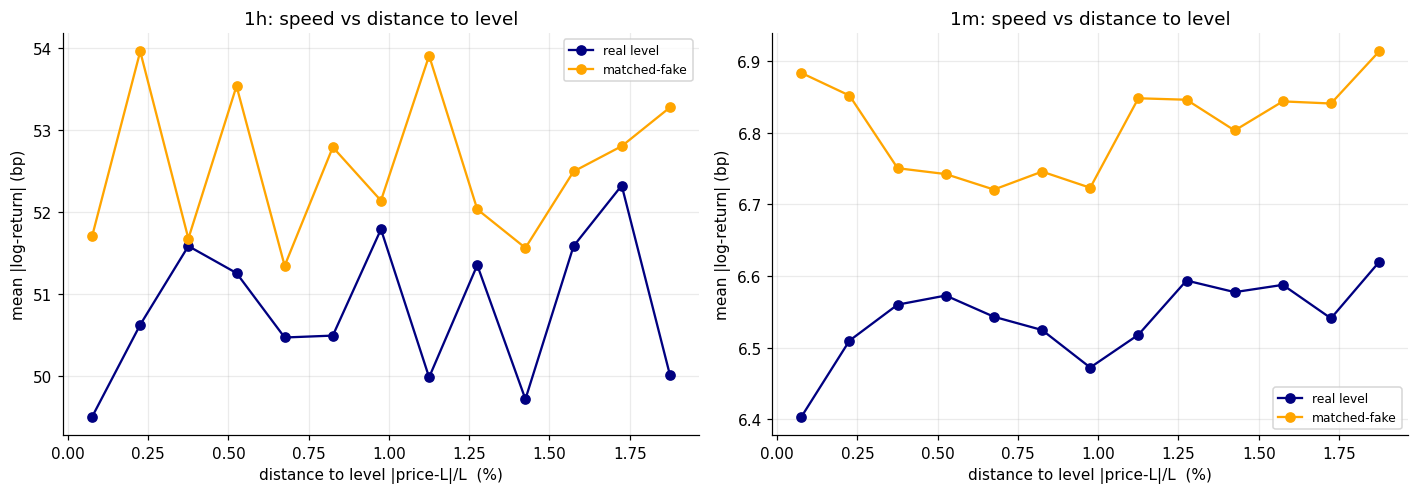

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for j, tf in enumerate(("1h", "1m")):
    pr = profile(tf, "real"); pm = profile(tf, "matched")
    ax[j].plot(centers, pr, "o-", color="navy", label="real level")
    ax[j].plot(centers, pm, "o-", color="orange", label="matched-fake")
    ax[j].set_title(f"{tf}: speed vs distance to level")
    ax[j].set_xlabel("distance to level |price-L|/L  (%)"); ax[j].set_ylabel("mean |log-return| (bp)")
    ax[j].legend(fontsize=8)
show("07_speed")

## Как читать / verdict

- Падение скорости у **малых dist** = торможение/поглощение у уровня.
- Важно сравнение real vs matched: если у real провал **глубже**, чем у matched на том
  же расстоянии → это эффект уровня, а не геометрии «близко к недавней цене».
- 1m тоньше ловит микро-замедление, чем 1h. Если и на 1m real ≈ matched → темп у
  уровня не меняется сверх расположения → сигнал (если есть) глубже OHLCV (стакан).